<a href="https://colab.research.google.com/github/darehanthe8955-jpg/Stock-Market-Analysis/blob/main/stock_market_analysis(nifty_50).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf

df = yf.download("^NSEI", period="1y", interval="1d")
df.info()
df.describe()
df

/tmp/ipykernel_4232/2099796280.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("^NSEI", period="1y", interval="1d")
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 247 entries, 2025-04-02 to 2026-04-02
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^NSEI)   247 non-null    float64
 1   (High, ^NSEI)    247 non-null    float64
 2   (Low, ^NSEI)     247 non-null    float64
 3   (Open, ^NSEI)    247 non-null    float64
 4   (Volume, ^NSEI)  247 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.6 KB


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2025-04-02,23332.349609,23350.000000,23158.449219,23192.599609,341000
2025-04-03,23250.099609,23306.500000,23145.800781,23150.300781,283200
2025-04-04,22904.449219,23214.699219,22857.449219,23190.400391,466800
2025-04-07,22161.599609,22254.000000,21743.650391,21758.400391,647100
2025-04-08,22535.849609,22697.199219,22270.849609,22446.750000,468300
...,...,...,...,...,...
2026-03-25,23306.449219,23465.349609,23063.199219,23064.400391,505400
2026-03-27,22819.599609,23186.099609,22804.550781,23173.550781,612600


In [ ]:
df.drop_duplicates()
df.dropna().copy()
df.reset_index(inplace =True)
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
0,2025-04-02,23332.349609,23350.000000,23158.449219,23192.599609,341000
1,2025-04-03,23250.099609,23306.500000,23145.800781,23150.300781,283200
2,2025-04-04,22904.449219,23214.699219,22857.449219,23190.400391,466800
3,2025-04-07,22161.599609,22254.000000,21743.650391,21758.400391,647100
4,2025-04-08,22535.849609,22697.199219,22270.849609,22446.750000,468300
...,...,...,...,...,...,...
242,2026-03-25,23306.449219,23465.349609,23063.199219,23064.400391,505400
243,2026-03-27,22819.599609,23186.099609,22804.550781,23173.550781,612600
244,2026-03-30,22331.400391,22714.099609,22283.849609,22549.650391,698600


In [ ]:
import pandas as pd


In [ ]:
df= df.sort_index()
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
0,2025-04-02,23332.349609,23350.000000,23158.449219,23192.599609,341000
1,2025-04-03,23250.099609,23306.500000,23145.800781,23150.300781,283200
2,2025-04-04,22904.449219,23214.699219,22857.449219,23190.400391,466800
3,2025-04-07,22161.599609,22254.000000,21743.650391,21758.400391,647100
4,2025-04-08,22535.849609,22697.199219,22270.849609,22446.750000,468300
...,...,...,...,...,...,...
242,2026-03-25,23306.449219,23465.349609,23063.199219,23064.400391,505400
243,2026-03-27,22819.599609,23186.099609,22804.550781,23173.550781,612600
244,2026-03-30,22331.400391,22714.099609,22283.849609,22549.650391,698600


In [ ]:
df["MA-50"] = df["Close"].rolling(window= 50).mean()
df["MA-200"] = df["Close"].rolling(window= 200).mean()

df["daily return"] = df["Close"].pct_change()
df["Volatility"] = df["daily return"].rolling(window = 20).std()

In [ ]:
import matplotlib.pyplot as plt

df["target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

In [ ]:
df = df.dropna().copy()
df.reset_index(drop=True, inplace=True)
df

Price,Date,Close,High,Low,Open,Volume,MA-50,MA-200,daily return,Volatility,target
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,,,,
0,2026-01-21,25157.500000,25300.949219,24919.800781,25141.000000,395600,25949.555156,25123.993311,-0.002972,0.005030,1
1,2026-01-22,25289.900391,25435.750000,25168.500000,25344.150391,486400,25941.454180,25133.781064,0.005263,0.005267,0
2,2026-01-23,25048.650391,25347.949219,25025.300781,25344.599609,393900,25924.911172,25142.773818,-0.009539,0.005549,1
3,2026-01-27,25175.400391,25246.650391,24932.550781,25063.349609,618700,25910.836172,25154.128574,0.005060,0.005757,1
4,2026-01-28,25342.750000,25372.099609,25187.650391,25258.849609,574900,25899.490156,25170.034326,0.006647,0.006021,1
5,2026-01-29,25418.900391,25458.150391,25159.800781,25345.000000,582400,25887.599180,25184.449580,0.003005,0.006089,0
6,2026-01-30,25320.650391,25370.699219,25213.650391,25247.550781,508400,25875.811172,25199.057080,-0.003865,0.005789,0
7,2026-02-02,25088.400391,25108.099609,24679.400391,24796.500000,449200,25856.526172,25210.356328,-0.009172,0.006005,1
8,2026-02-03,25727.550781,26341.199219,25641.300781,26308.050781,637300,25847.234180,25222.351328,0.025476,0.008411,1


In [ ]:
features = ['MA-50', 'MA-200', 'Volatility']

X = df[features]
y = df['target']

In [ ]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5


In [ ]:
df_test = df.iloc[split:].copy()
df_test.reset_index(drop=True, inplace=True)

df_test['Prediction'] = y_pred
df

Price,Date,Close,High,Low,Open,Volume,MA-50,MA-200,daily return,Volatility,target
Ticker,,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI,,,,,
0,2026-01-21,25157.500000,25300.949219,24919.800781,25141.000000,395600,25949.555156,25123.993311,-0.002972,0.005030,1
1,2026-01-22,25289.900391,25435.750000,25168.500000,25344.150391,486400,25941.454180,25133.781064,0.005263,0.005267,0
2,2026-01-23,25048.650391,25347.949219,25025.300781,25344.599609,393900,25924.911172,25142.773818,-0.009539,0.005549,1
3,2026-01-27,25175.400391,25246.650391,24932.550781,25063.349609,618700,25910.836172,25154.128574,0.005060,0.005757,1
4,2026-01-28,25342.750000,25372.099609,25187.650391,25258.849609,574900,25899.490156,25170.034326,0.006647,0.006021,1
5,2026-01-29,25418.900391,25458.150391,25159.800781,25345.000000,582400,25887.599180,25184.449580,0.003005,0.006089,0
6,2026-01-30,25320.650391,25370.699219,25213.650391,25247.550781,508400,25875.811172,25199.057080,-0.003865,0.005789,0
7,2026-02-02,25088.400391,25108.099609,24679.400391,24796.500000,449200,25856.526172,25210.356328,-0.009172,0.006005,1
8,2026-02-03,25727.550781,26341.199219,25641.300781,26308.050781,637300,25847.234180,25222.351328,0.025476,0.008411,1


In [ ]:
df.columns = df.columns.get_level_values(0)
df

Price,Date,Close,High,Low,Open,Volume,MA-50,MA-200,daily return,Volatility,target
0,2026-01-21,25157.500000,25300.949219,24919.800781,25141.000000,395600,25949.555156,25123.993311,-0.002972,0.005030,1
1,2026-01-22,25289.900391,25435.750000,25168.500000,25344.150391,486400,25941.454180,25133.781064,0.005263,0.005267,0
2,2026-01-23,25048.650391,25347.949219,25025.300781,25344.599609,393900,25924.911172,25142.773818,-0.009539,0.005549,1
3,2026-01-27,25175.400391,25246.650391,24932.550781,25063.349609,618700,25910.836172,25154.128574,0.005060,0.005757,1
4,2026-01-28,25342.750000,25372.099609,25187.650391,25258.849609,574900,25899.490156,25170.034326,0.006647,0.006021,1
5,2026-01-29,25418.900391,25458.150391,25159.800781,25345.000000,582400,25887.599180,25184.449580,0.003005,0.006089,0
6,2026-01-30,25320.650391,25370.699219,25213.650391,25247.550781,508400,25875.811172,25199.057080,-0.003865,0.005789,0
7,2026-02-02,25088.400391,25108.099609,24679.400391,24796.500000,449200,25856.526172,25210.356328,-0.009172,0.006005,1
8,2026-02-03,25727.550781,26341.199219,25641.300781,26308.050781,637300,25847.234180,25222.351328,0.025476,0.008411,1
9,2026-02-04,25776.000000,25818.550781,25563.949219,25675.050781,429800,25841.391172,25234.045332,0.001883,0.008425,0


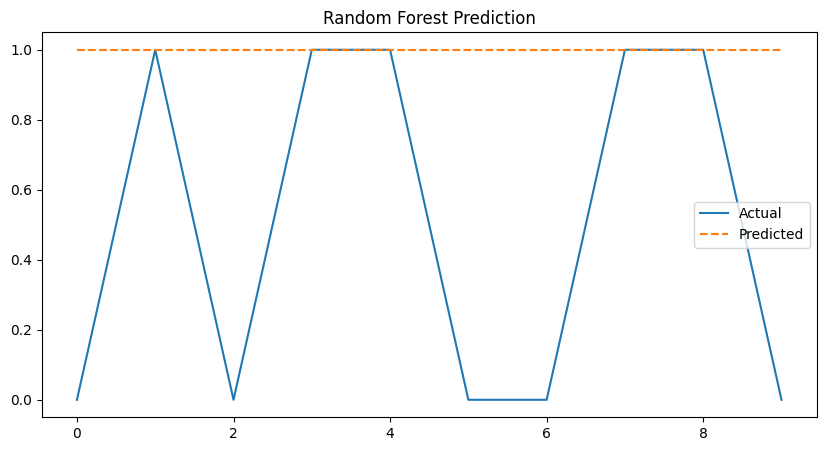

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_test['target'].values, label='Actual')
plt.plot(df_test['Prediction'].values, label='Predicted', linestyle='--')

plt.legend()
plt.title("Random Forest Prediction")
plt.show()

In [ ]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Price       Ticker
MA-200                0.382860
MA-50                 0.309933
Volatility            0.307207
dtype: float64


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.50      1.00      0.67         5

    accuracy                           0.50        10
   macro avg       0.25      0.50      0.33        10
weighted avg       0.25      0.50      0.33        10


Confusion Matrix:
 [[0 5]
 [0 5]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
